#Source:https://matplotlib.org/stable/users/explain/colors/colormaps.html#colormaps

In [1]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'okabe_ito',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays

<h2>Overview</h2>
Color can be represented in 3D space in various ways. One way to represent color is using CIELAB. In CIELAB, color space is represented by lightness, 
𝐿∗
; red-green, 
𝑎∗
; and yellow-blue, 
𝑏∗
. The lightness parameter 
𝐿∗
 can then be used to learn more about how the matplotlib colormaps will be perceived by viewers.

<h2>Classes of colormaps</h2>

Colormaps are often split into several categories based on their function

Sequential: change in lightness and often saturation of color incrementally, often using a single hue; should be used for representing information that has ordering.

Diverging: change in lightness and possibly saturation of two different colors that meet in the middle at an unsaturated color; should be used when the information being plotted has a critical middle value, such as topography or when the data deviates around zero.

Cyclic: change in lightness of two different colors that meet in the middle and beginning/end at an unsaturated color; should be used for values that wrap around at the endpoints, such as phase angle, wind direction, or time of day.

Qualitative: often are miscellaneous colors; should be used to represent information which does not have ordering or relationships.


In [2]:
from colorspacious import cspace_converter

import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl

First, we'll show the range of each colormap. Note that some seem to change more "quickly" than others.

In [16]:
cmaps = {}

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))


def plot_color_gradients(category, cmap_list):
    # Create figure and adjust figure height to number of colormaps
    nrows = len(cmap_list)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh,
                        left=0.2, right=0.99)
    axs[0].set_title(f'{category} colormaps', fontsize=14)

    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect='auto', cmap=mpl.colormaps[name])
        ax.text(-0.01, 0.5, name, va='center', ha='right', fontsize=10,
                transform=ax.transAxes)

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs:
        ax.set_axis_off()

    # Save colormap list for later.
    cmaps[category] = cmap_list
        

<h4>Sequential</h4>

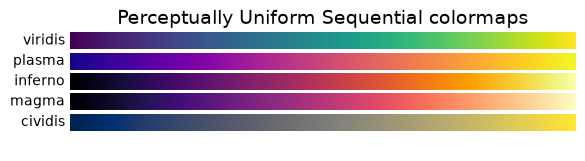

In [17]:
plot_color_gradients('Perceptually Uniform Sequential',
                     ['viridis', 'plasma', 'inferno', 'magma', 'cividis'])

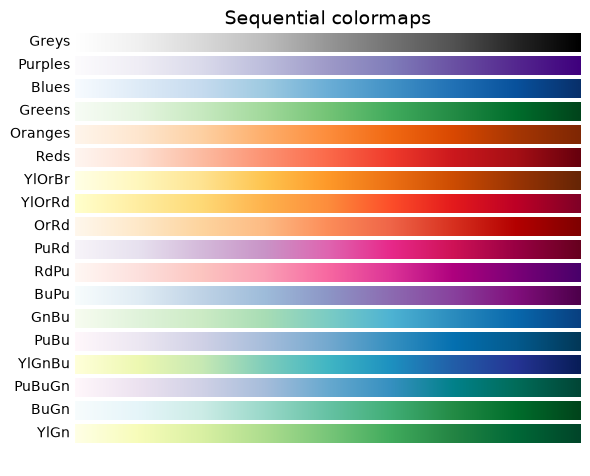

In [18]:
plot_color_gradients('Sequential',
                     ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
                      'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
                      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn'])

<h2>Sequential2</h2>

Many of the 𝐿∗ values from the Sequential2 plots are monotonically increasing, but some (autumn, cool, spring, and winter) plateau or even go both up and down in 𝐿∗ space. Others (afmhot, copper, gist_heat, and hot) have kinks in the 𝐿∗  functions. Data that is being represented in a region of the colormap that is at a plateau or kink will lead to a perception of banding of the data in those values in the colormap (see [mycarta-banding] for an excellent example of this).

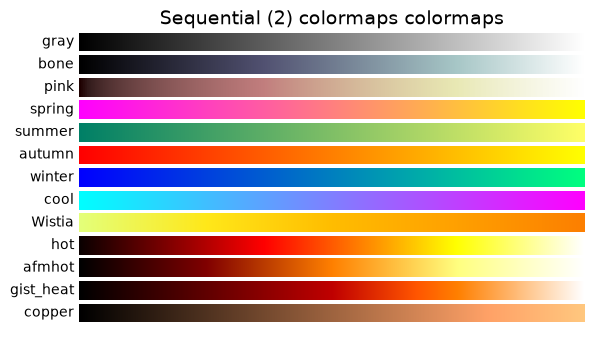

In [19]:
plot_color_gradients('Sequential (2) colormaps',
                     ['gray', 'bone', 'pink', 'spring', 'summer', 'autumn',
                      'winter', 'cool', 'Wistia', 'hot', 'afmhot', 'gist_heat',
                      'copper'])

<h2>Diverging</h2>

For the Diverging maps, we want to have monotonically increasing 𝐿∗ values up to a maximum, which should be close to 𝐿∗ =100 , followed by monotonically decreasing 𝐿∗ values. We are looking for approximately equal minimum 𝐿∗ values at opposite ends of the colormap. By these measures, BrBG and RdBu are good options. coolwarm is a good option, but it doesn't span a wide range of 
𝐿∗ values (see grayscale section below).

Berlin, Managua, and Vanimo are dark-mode diverging colormaps, with minimum lightness at the center, and maximum at the extremes. These are taken from F. Crameri's [scientific-colour-maps] version 8.0.1.

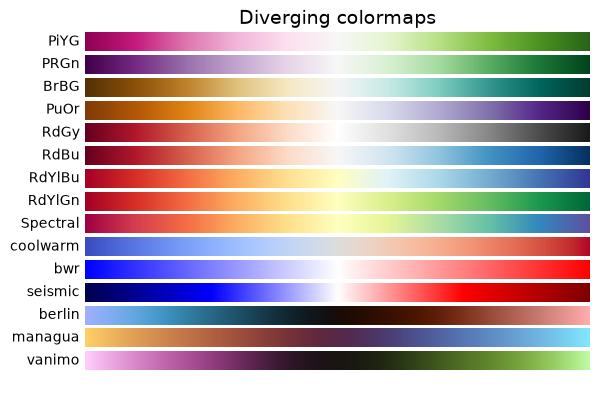

In [20]:
plot_color_gradients('Diverging',
                     ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu',
                      'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic',
                      'berlin', 'managua', 'vanimo'])

<h2>Cyclic</h2>

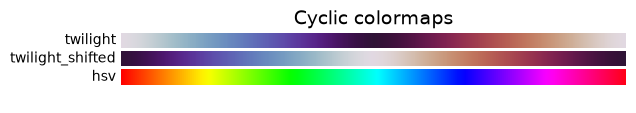

In [22]:
plot_color_gradients('Cyclic',['twilight','twilight_shifted','hsv'])

<h2>Qualitative</h2>

Qualitative colormaps are not aimed at being perceptual maps, but looking at the lightness parameter can verify that for us. The 𝐿∗ values move all over the place throughout the colormap, and are clearly not monotonically increasing. These would not be good options for use as perceptual colormaps.

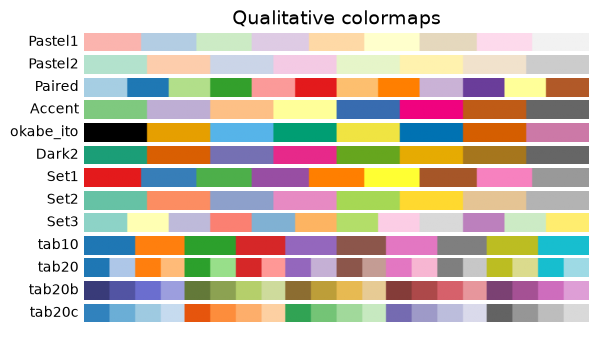

In [26]:
plot_color_gradients('Qualitative',
                   ['Pastel1','Pastel2','Paired', 'Accent','okabe_ito',
                   'Dark2','Set1','Set2','Set3','tab10','tab20',
                    'tab20b','tab20c'])